In [1]:
from time import time
import mininumpy as mnp
import random
import matplotlib.pyplot as plt

In [2]:
n = [2, 3, 4, 5, 6, 7]
n_gau = [150, 160, 170, 180, 190, 200]

# Build test matrices
tests = [
    [mnp.Array([[random.random() for _ in range(N)] for _ in range(N)]) for N in n],
    [mnp.Array([[random.random() for _ in range(N)] for _ in range(N)]) for N in n_gau]
]

det = {}
timer = {}

for algo in ['recursion', 'LU', 'gaussian']:

    det[algo] = []
    timer[algo] = []

    # choose the correct test size group
    if algo == 'recursion':
        dataset = tests[0]      # small matrices
    else:
        dataset = tests[1]      # large matrices

    for i in range(len(dataset)):

        start = time()
        d = mnp.minilinalg.inv(dataset[i], algo=algo)
        stop = time()

        det[algo].append(d)
        timer[algo].append(stop - start)

In [3]:
print(timer)
print(det)

{'recursion': [8.320808410644531e-05, 0.00017976760864257812, 0.00039315223693847656, 0.0011265277862548828, 0.0028672218322753906, 0.006531476974487305], 'LU': [1.389162540435791, 1.6965739727020264, 2.184351682662964, 2.620025873184204, 3.1108477115631104, 3.681493043899536], 'gaussian': [7.652039051055908, 9.272849798202515, 11.213228702545166, 13.285768270492554, 15.80230450630188, 18.31211519241333]}
{'recursion': [<mininumpy.array.Array object at 0x00000276FFE43E70>, <mininumpy.array.Array object at 0x00000276FFE42660>, <mininumpy.array.Array object at 0x00000276FFE42C10>, <mininumpy.array.Array object at 0x00000276FFE42F20>, <mininumpy.array.Array object at 0x00000276FFE42EB0>, <mininumpy.array.Array object at 0x00000276FFE43070>], 'LU': [<mininumpy.array.Array object at 0x00000276FFE426D0>, <mininumpy.array.Array object at 0x00000276FFE430E0>, <mininumpy.array.Array object at 0x00000276FFE42190>, <mininumpy.array.Array object at 0x00000276FFE43150>, <mininumpy.array.Array objec

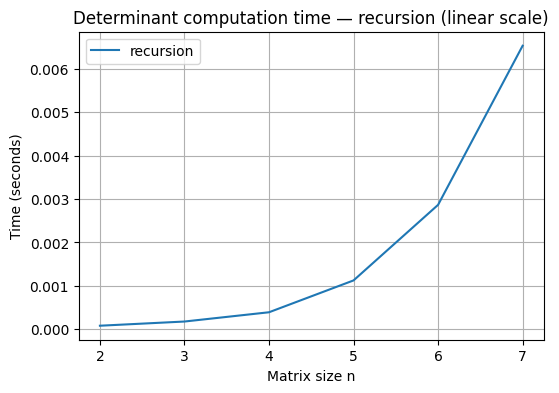

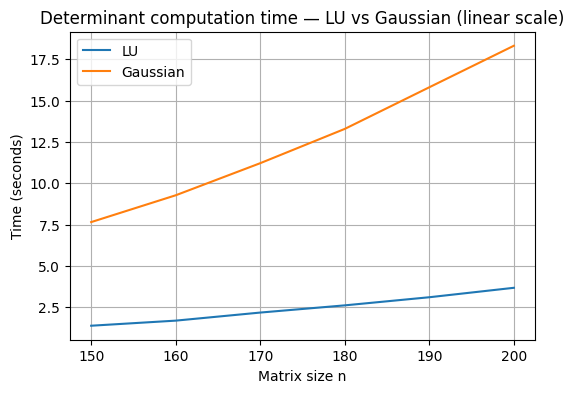

In [4]:
# --- Plot 1: recursion alone ---
plt.figure(figsize=(6,4))
plt.plot(n, timer["recursion"], label="recursion")
plt.xlabel("Matrix size n")
plt.ylabel("Time (seconds)")
plt.title("Determinant computation time — recursion (linear scale)")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot 2: LU + Gaussian together ---
plt.figure(figsize=(6,4))
plt.plot(n_gau, timer["LU"], label="LU")
plt.plot(n_gau, timer["gaussian"], label="Gaussian")
plt.xlabel("Matrix size n")
plt.ylabel("Time (seconds)")
plt.title("Determinant computation time — LU vs Gaussian (linear scale)")
plt.legend()
plt.grid(True)
plt.show()